In [1]:
import os
import pandas as pd

In [2]:
# 1. 디렉토리 경로 설정
directory_path = '/Users/khj/Desktop/Project_ongoing/DRBP/DRBP_Prediction/New_DRBP_result'  # 여기에 실제 경로 입력

# 2. 파일 목록 가져오기
all_files = [f for f in os.listdir(directory_path) if f.endswith('.csv')]

# 3. 파일 읽고 source 열 추가
df_list = []
for file in all_files:
    file_path = os.path.join(directory_path, file)
    
    if file.startswith("DBP"):
        source_label = "DBP"
    elif file.startswith("RBP"):
        source_label = "RBP"
    else:
        continue  # 둘 다 아니면 생략
    
    df = pd.read_csv(file_path)
    df["source"] = source_label
    df_list.append(df)

# 4. 하나로 합치기
merged_df = pd.concat(df_list, ignore_index=True)

merged_df

,ID,sequence,class,predictions,probabilities,source
0,>ENSP00000445508,MSRSPDAKEDPVECPLCMEPLEIDDINFFPCTCGYQICRFCWHRIR...,1,1.0,0.988484,RBP
1,>ENSP00000332340,MALTRPVRLFSLVTRLLLAPRRGLTVRSPDEPLPVVRIPVALQRQL...,1,1.0,0.963513,RBP
2,>ENSP00000330460,MFVPRSLKIKRNANDDGKSCVAKIIKPDPEDLQLDKSRDVPVDAVA...,1,1.0,0.810341,RBP
3,>ENSP00000250113,MGGLASGGDVEPGLPVEVRGSNGAFYKGFVKDVHEDSVTIFFENNW...,1,1.0,0.997666,RBP
4,>ENSP00000377275,MLSRLSGLANVVLHELSGDDDTDQNMRAPLDPELHQESDMEFNNTT...,1,0.0,0.000341,RBP
...,...,...,...,...,...,...
36437,>ENSP00000215570,MEGGFGSDFGGSGSGKLDPGLIMEQVKVQIAVANAQELLQRMTDKC...,0,0.0,0.021219,RBP
36438,>ENSP00000309092,MKALILVGGYGTRLRPLTLSTPKPLVDFCNKPILLHQVEALAAAGV...,0,0.0,0.155722,RBP
36439,>ENSP00000366748,MELPSGPGPERLFDSHRLPGDCFLLLVLLLYAPVGFCLLVLRLFLG...,0,0.0,0.002969,RBP
36440,>ENSP00000358071,MAERKPNGGSGGASTSSSGTNLLFSSSATEFSFNVPFIPVTQASAS...,0,0.0,0.081570,RBP


In [3]:
rbp_df = merged_df[merged_df['source']=='RBP']
dbp_df = merged_df[merged_df['source']=='DBP']
dbp_df = dbp_df.sort_values(by='ID').reset_index(drop=True)
rbp_df = rbp_df.sort_values(by='ID').reset_index(drop=True)
rbp_df

,ID,sequence,class,predictions,probabilities,source
0,>ENSP00000000233,MGLTVSALFSRIFGKKQMRILMVGLDAAGKTTILYKLKLGEIVTTI...,0,0.0,0.000058,RBP
1,>ENSP00000000412,MFPFYSCWRTGLLLLLLAVAVRESWQTEEKTCDLVGEKGKESEKEL...,0,0.0,0.000553,RBP
2,>ENSP00000000442,MSSQVVGIEPLYIKAEPASPDSPKGSSETETEPPVALAPGPAPTRC...,0,0.0,0.000091,RBP
3,>ENSP00000001008,MTAEEMKATESGAQSAPLPMEGVDISPKQDEGVLKVIKREGTGTEM...,1,0.0,0.000029,RBP
4,>ENSP00000001146,MLFEGLDLVSALATLAACLVSVTLLLAVSQQLWQLRWAATRDKSCK...,0,0.0,0.020440,RBP
...,...,...,...,...,...,...
18216,>ENSP00000498164,MAAPVVAPPGVVVSRANKRSGAGPGGSGGGGARGAEEEPPPPLQAV...,0,0.0,0.010683,RBP
18217,>ENSP00000498177,MKFNPFVTSDRSKNRKRHFNAPSHIRRKIMSSPLSKELRQKYNVRS...,0,0.0,0.473582,RBP
18218,>ENSP00000498186,MQLRNPELHLGCALALRFLALVSWDIPGARALDNGLARTPTMGWLH...,0,0.0,0.010173,RBP
18219,>ENSP00000498190,MSPSLQEGAQLGENKPSTCSFSIERILGLDQKKDCVPLMKPHRPWA...,0,0.0,0.001034,RBP


In [4]:
dbp_df.columns = ['ID','sequence','DNA-binding','DNA-binding prediction','DNA-binding probabilities','source']
dbp_df['RNA-binding'] = rbp_df['class']
dbp_df['RNA-binding prediction'] = rbp_df['predictions']
dbp_df['RNA-binding probabilities'] = rbp_df['probabilities']
dbp_df

,ID,sequence,DNA-binding,DNA-binding prediction,DNA-binding probabilities,source,RNA-binding,RNA-binding prediction,RNA-binding probabilities
0,>ENSP00000000233,MGLTVSALFSRIFGKKQMRILMVGLDAAGKTTILYKLKLGEIVTTI...,0,0.0,0.197959,DBP,0,0.0,0.000058
1,>ENSP00000000412,MFPFYSCWRTGLLLLLLAVAVRESWQTEEKTCDLVGEKGKESEKEL...,0,0.0,0.026668,DBP,0,0.0,0.000553
2,>ENSP00000000442,MSSQVVGIEPLYIKAEPASPDSPKGSSETETEPPVALAPGPAPTRC...,1,1.0,0.947597,DBP,0,0.0,0.000091
3,>ENSP00000001008,MTAEEMKATESGAQSAPLPMEGVDISPKQDEGVLKVIKREGTGTEM...,0,0.0,0.469457,DBP,1,0.0,0.000029
4,>ENSP00000001146,MLFEGLDLVSALATLAACLVSVTLLLAVSQQLWQLRWAATRDKSCK...,0,0.0,0.078130,DBP,0,0.0,0.020440
...,...,...,...,...,...,...,...,...,...
18216,>ENSP00000498164,MAAPVVAPPGVVVSRANKRSGAGPGGSGGGGARGAEEEPPPPLQAV...,0,0.0,0.237524,DBP,0,0.0,0.010683
18217,>ENSP00000498177,MKFNPFVTSDRSKNRKRHFNAPSHIRRKIMSSPLSKELRQKYNVRS...,0,1.0,0.721043,DBP,0,0.0,0.473582
18218,>ENSP00000498186,MQLRNPELHLGCALALRFLALVSWDIPGARALDNGLARTPTMGWLH...,0,0.0,0.084342,DBP,0,0.0,0.010173
18219,>ENSP00000498190,MSPSLQEGAQLGENKPSTCSFSIERILGLDQKKDCVPLMKPHRPWA...,0,1.0,0.935315,DBP,0,0.0,0.001034


In [5]:
model_prediction = dbp_df.copy()
model_prediction = model_prediction[['ID','sequence','DNA-binding','RNA-binding','DNA-binding probabilities','RNA-binding probabilities']]
df = model_prediction.copy()
df

,ID,sequence,DNA-binding,RNA-binding,DNA-binding probabilities,RNA-binding probabilities
0,>ENSP00000000233,MGLTVSALFSRIFGKKQMRILMVGLDAAGKTTILYKLKLGEIVTTI...,0,0,0.197959,0.000058
1,>ENSP00000000412,MFPFYSCWRTGLLLLLLAVAVRESWQTEEKTCDLVGEKGKESEKEL...,0,0,0.026668,0.000553
2,>ENSP00000000442,MSSQVVGIEPLYIKAEPASPDSPKGSSETETEPPVALAPGPAPTRC...,1,0,0.947597,0.000091
3,>ENSP00000001008,MTAEEMKATESGAQSAPLPMEGVDISPKQDEGVLKVIKREGTGTEM...,0,1,0.469457,0.000029
4,>ENSP00000001146,MLFEGLDLVSALATLAACLVSVTLLLAVSQQLWQLRWAATRDKSCK...,0,0,0.078130,0.020440
...,...,...,...,...,...,...
18216,>ENSP00000498164,MAAPVVAPPGVVVSRANKRSGAGPGGSGGGGARGAEEEPPPPLQAV...,0,0,0.237524,0.010683
18217,>ENSP00000498177,MKFNPFVTSDRSKNRKRHFNAPSHIRRKIMSSPLSKELRQKYNVRS...,0,0,0.721043,0.473582
18218,>ENSP00000498186,MQLRNPELHLGCALALRFLALVSWDIPGARALDNGLARTPTMGWLH...,0,0,0.084342,0.010173
18219,>ENSP00000498190,MSPSLQEGAQLGENKPSTCSFSIERILGLDQKKDCVPLMKPHRPWA...,0,0,0.935315,0.001034


In [ ]:
df.to_csv('new_drbp_predicted_result.csv',index=None)

In [6]:
df = pd.read_csv('new_drbp_predicted_result.csv')
df

,ID,sequence,DNA-binding,RNA-binding,DNA-binding probabilities,RNA-binding probabilities
0,>ENSP00000000233,MGLTVSALFSRIFGKKQMRILMVGLDAAGKTTILYKLKLGEIVTTI...,0,0,0.197959,0.000058
1,>ENSP00000000412,MFPFYSCWRTGLLLLLLAVAVRESWQTEEKTCDLVGEKGKESEKEL...,0,0,0.026668,0.000553
2,>ENSP00000000442,MSSQVVGIEPLYIKAEPASPDSPKGSSETETEPPVALAPGPAPTRC...,1,0,0.947597,0.000091
3,>ENSP00000001008,MTAEEMKATESGAQSAPLPMEGVDISPKQDEGVLKVIKREGTGTEM...,0,1,0.469457,0.000029
4,>ENSP00000001146,MLFEGLDLVSALATLAACLVSVTLLLAVSQQLWQLRWAATRDKSCK...,0,0,0.078130,0.020440
...,...,...,...,...,...,...
18216,>ENSP00000498164,MAAPVVAPPGVVVSRANKRSGAGPGGSGGGGARGAEEEPPPPLQAV...,0,0,0.237524,0.010683
18217,>ENSP00000498177,MKFNPFVTSDRSKNRKRHFNAPSHIRRKIMSSPLSKELRQKYNVRS...,0,0,0.721043,0.473582
18218,>ENSP00000498186,MQLRNPELHLGCALALRFLALVSWDIPGARALDNGLARTPTMGWLH...,0,0,0.084342,0.010173
18219,>ENSP00000498190,MSPSLQEGAQLGENKPSTCSFSIERILGLDQKKDCVPLMKPHRPWA...,0,0,0.935315,0.001034


In [7]:
mapped_data = pd.read_csv('/Users/khj/Desktop/Project_ongoing/DRBP/data/ENSP2uniprotID/uniprotID_merge.csv')
mapped_data = mapped_data[(mapped_data['Source']=='DBP')|(mapped_data['Source']=='NDBP')]
mapped_data['From'] = '>' + mapped_data['From']
dict_map = pd.Series(mapped_data['Entry'].values, index=mapped_data['From']).to_dict()
len(dict_map)

17718

In [8]:
df['Uniprot'] = '-'
df = df[['ID','Uniprot','sequence','DNA-binding','RNA-binding','DNA-binding probabilities','RNA-binding probabilities']]
df['Uniprot'] = df['ID'].map(dict_map).fillna('-')
df

,ID,Uniprot,sequence,DNA-binding,RNA-binding,DNA-binding probabilities,RNA-binding probabilities
0,>ENSP00000000233,P84085,MGLTVSALFSRIFGKKQMRILMVGLDAAGKTTILYKLKLGEIVTTI...,0,0,0.197959,0.000058
1,>ENSP00000000412,P20645,MFPFYSCWRTGLLLLLLAVAVRESWQTEEKTCDLVGEKGKESEKEL...,0,0,0.026668,0.000553
2,>ENSP00000000442,P11474,MSSQVVGIEPLYIKAEPASPDSPKGSSETETEPPVALAPGPAPTRC...,1,0,0.947597,0.000091
3,>ENSP00000001008,Q02790,MTAEEMKATESGAQSAPLPMEGVDISPKQDEGVLKVIKREGTGTEM...,0,1,0.469457,0.000029
4,>ENSP00000001146,Q9NR63,MLFEGLDLVSALATLAACLVSVTLLLAVSQQLWQLRWAATRDKSCK...,0,0,0.078130,0.020440
...,...,...,...,...,...,...,...
18216,>ENSP00000498164,A0A3B3IUB1,MAAPVVAPPGVVVSRANKRSGAGPGGSGGGGARGAEEEPPPPLQAV...,0,0,0.237524,0.010683
18217,>ENSP00000498177,P61254,MKFNPFVTSDRSKNRKRHFNAPSHIRRKIMSSPLSKELRQKYNVRS...,0,0,0.721043,0.473582
18218,>ENSP00000498186,A0A3B3IUC4,MQLRNPELHLGCALALRFLALVSWDIPGARALDNGLARTPTMGWLH...,0,0,0.084342,0.010173
18219,>ENSP00000498190,Q9UBX0,MSPSLQEGAQLGENKPSTCSFSIERILGLDQKKDCVPLMKPHRPWA...,0,0,0.935315,0.001034


In [9]:
len(df[(df['DNA-binding']==1)&df['RNA-binding']==1])

90

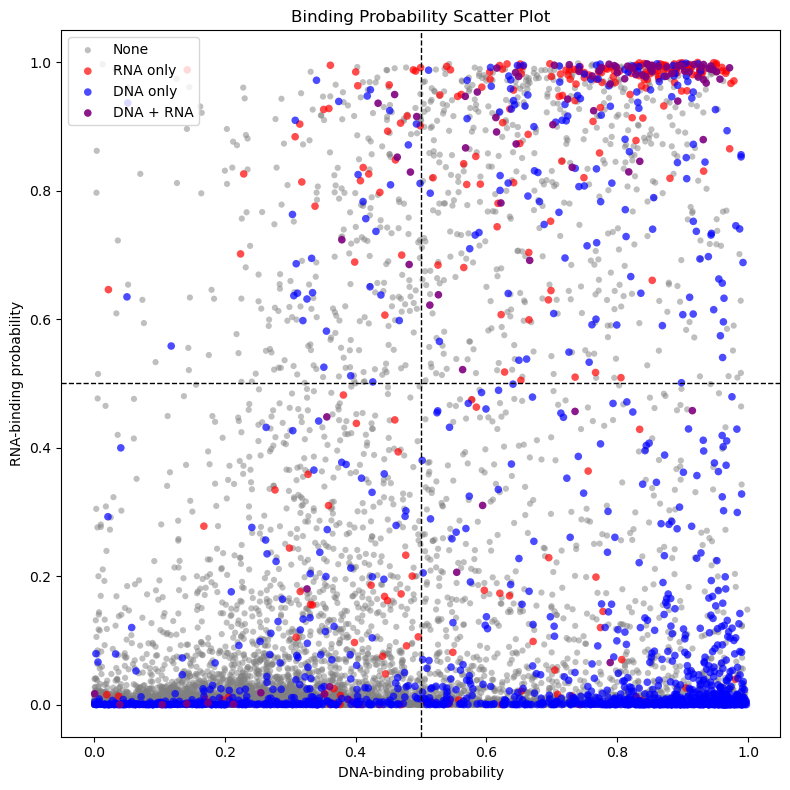

In [10]:
import pandas as pd
import matplotlib.pyplot as plt

# 색상 그룹 분리
purple_df = df[(df['DNA-binding'] == 1) & (df['RNA-binding'] == 1)]
blue_df   = df[(df['DNA-binding'] == 1) & (df['RNA-binding'] == 0)]
red_df    = df[(df['DNA-binding'] == 0) & (df['RNA-binding'] == 1)]
gray_df   = df[(df['DNA-binding'] == 0) & (df['RNA-binding'] == 0)]

# 시각화
fig, ax = plt.subplots(figsize=(8, 8))

# 우선순위대로 그리기: gray → red → blue → purple
ax.scatter(gray_df['DNA-binding probabilities'], gray_df['RNA-binding probabilities'], 
           color='gray', alpha=0.5, edgecolors='none', s=20, label='None')

ax.scatter(red_df['DNA-binding probabilities'], red_df['RNA-binding probabilities'], 
           color='red', alpha=0.7, edgecolors='none', s=30, label='RNA only')

ax.scatter(blue_df['DNA-binding probabilities'], blue_df['RNA-binding probabilities'], 
           color='blue', alpha=0.7, edgecolors='none', s=30, label='DNA only')

ax.scatter(purple_df['DNA-binding probabilities'], purple_df['RNA-binding probabilities'], 
           color='purple', alpha=0.9, edgecolors='none', s=30, label='DNA + RNA')

# 기준선
ax.axvline(x=0.5, color='black', linestyle='--', linewidth=1)
ax.axhline(y=0.5, color='black', linestyle='--', linewidth=1)

# 라벨 및 기타 설정
ax.set_xlabel('DNA-binding probability')
ax.set_ylabel('RNA-binding probability')
ax.set_title('Binding Probability Scatter Plot')
ax.legend()
plt.tight_layout()
plt.show()